In [41]:
data_directory = "data/ravdess"

In [42]:
root_path = '/'

In [43]:
import os
os.chdir(root_path)

In [44]:
!pip install PyDrive

In [45]:
from google.colab import drive
drive.mount('content/gdrive')

Drive already mounted at content/gdrive; to attempt to forcibly remount, call drive.mount("content/gdrive", force_remount=True).


In [46]:
!pip install pydrive2

# Authenticate and create Google Drive client
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

In [47]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [48]:
if not os.path.exists('data'):
    os.makedirs('data')

downloaded = drive.CreateFile({'id':"1-AfZkAHacvUtxJNM_B5xRF6_B0Ra6lk6"})
downloaded.GetContentFile('speech-emotion-recognition-dataset.zip')

!mv speech-emotion-recognition-dataset.zip data

if not os.path.exists(data_directory):
    os.makedirs(data_directory)

!unzip data/speech-emotion-recognition-dataset.zip -d data/ravdess

Archive:  data/speech-emotion-recognition-dataset.zip
replace data/ravdess/Actor_01/03-01-01-01-01-01-01.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [49]:
import librosa
import soundfile
import os, glob, pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix, f1_score
import pickle
import keras
from keras import layers, Sequential
from keras.layers import Conv1D, Activation, Dropout, Dense, Flatten, MaxPooling1D
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# Import to_categorical directly from keras.utils
from keras.utils import to_categorical
from tensorflow.keras import regularizers
from matplotlib import pyplot as plt
import seaborn as sn
import pandas as pd
import sklearn.metrics as metrics
# Make sure TensorFlow is imported
import tensorflow as tf

In [51]:
import warnings

In [52]:
# Suppress Librosa warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [53]:
def extract_feature(data, sr, mfcc=True, chroma=True, mel=True):
    """
    Extract features from audio files into numpy array with error handling
    """
    result = np.array([])

    try:
        if mfcc:
            mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
            result = np.hstack((result, mfccs))

        if chroma:
            stft = np.abs(librosa.stft(data))
            chroma_feat = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
            result = np.hstack((result, chroma_feat))

        if mel:
            mel_spec = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T, axis=0)
            result = np.hstack((result, mel_spec))

    except Exception as e:
        print(f"Error extracting features: {e}")
        # Return zero array of expected shape if feature extraction fails
        expected_length = 0
        if mfcc: expected_length += 40
        if chroma: expected_length += 12
        if mel: expected_length += 128
        return np.zeros(expected_length)

    return result

In [54]:
def load_data(save=False, augment=True):
    """
    Improved load_data function with better error handling
    """
    x, y = [], []
    emotion_dict = {
        '01': 'neutral',
        '02': 'calm',
        '03': 'happy',
        '04': 'sad',
        '05': 'angry',
        '06': 'fearful',
        '07': 'disgust',
        '08': 'surprised'
    }

    for file in glob.glob(os.path.join(data_directory, "Actor_*/*.wav")):
        try:
            data, sr = librosa.load(file, sr=None)  # Keep original sample rate

            # Original features
            feature = extract_feature(data, sr)
            if feature is not None:
                x.append(feature)
                y.append(emotion_dict[os.path.basename(file).split("-")[2]])

            if augment:
                # Noise augmentation
                n_data = data + 0.001 * np.random.randn(len(data))
                n_feature = extract_feature(n_data, sr)
                if n_feature is not None:
                    x.append(n_feature)
                    y.append(emotion_dict[os.path.basename(file).split("-")[2]])

                # Shift augmentation
                s_data = np.roll(data, int(sr * 0.25))
                s_data[:int(sr * 0.25)] = 0
                s_feature = extract_feature(s_data, sr)
                if s_feature is not None:
                    x.append(s_feature)
                    y.append(emotion_dict[os.path.basename(file).split("-")[2]])

        except Exception as e:
            print(f"Error processing {file}: {e}")
            continue

    if save:
        np.save('X.npy', np.array(x))
        np.save('y.npy', np.array(y))

    return np.array(x), np.array(y)

# Load data
try:
    X = np.load("X.npy")
    y = np.load("y.npy")
    print("Loaded preprocessed data from disk")
except:
    print("Processing data from scratch...")
    X, y = load_data(save=True)
    print(f"Data loaded. X shape: {X.shape}, y shape: {y.shape}")

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=9,
    stratify=y
)

print(f"Train shapes: {x_train.shape}, {y_train.shape}")
print(f"Test shapes: {x_test.shape}, {y_test.shape}")

Loaded preprocessed data from disk
Train shapes: (3240, 180), (3240,)
Test shapes: (1080, 180), (1080,)


In [55]:
labelencoder = LabelEncoder()
labelencoder.fit(y_train)
le_name_mapping = dict(zip(labelencoder.classes_, labelencoder.transform(labelencoder.classes_)))
print(le_name_mapping)

y_train = labelencoder.transform(y_train)
y_test = labelencoder.transform(y_test)

{np.str_('angry'): np.int64(0), np.str_('calm'): np.int64(1), np.str_('disgust'): np.int64(2), np.str_('fearful'): np.int64(3), np.str_('happy'): np.int64(4), np.str_('neutral'): np.int64(5), np.str_('sad'): np.int64(6), np.str_('surprised'): np.int64(7)}


In [56]:
# Get the number of features extracted
print(f'Features extracted: {x_train.shape[1]}')

Features extracted: 180


In [58]:
model = Sequential()
model.add(Conv1D(256, 5,padding='same', input_shape=(180,1))) # 1st layer
model.add(Activation('relu'))
model.add(Conv1D(128, 5,padding='same', kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4))) # 2nd layer
model.add(Activation('relu'))
model.add(Dropout(0.1))
model.add(MaxPooling1D(pool_size=(8)))
model.add(Conv1D(128, 5,padding='same', kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4))) # 3rd layer
model.add(Activation('relu'))
model.add(Conv1D(128, 5,padding='same', kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4))) # 4th layer
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(units=8,
                kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4),
                bias_regularizer=regularizers.l2(1e-4),
                activity_regularizer=regularizers.l2(1e-5)
                )
) # 7th layer
model.add(Activation('softmax'))
# Instantiate the Adam optimizer directly from tensorflow.keras.optimizers
opt = tf.keras.optimizers.Adam(decay=1e-6)

In [59]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=opt,metrics=['accuracy'])

In [60]:
XProccessed = np.expand_dims(x_train, axis=2)
XTestProcessed = np.expand_dims(x_test, axis=2)
history = model.fit(XProccessed, y_train, epochs=100, validation_data=(XTestProcessed, y_test), batch_size=64)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 29s 420ms/step - accuracy: 0.1703 - loss: 2.8702 - val_accuracy: 0.2963 - val_loss: 1.9941
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 45s 502ms/step - accuracy: 0.3107 - loss: 1.9752 - val_accuracy: 0.3731 - val_loss: 1.8469
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 556ms/step - accuracy: 0.3616 - loss: 1.8064 - val_accuracy: 0.3824 - val_loss: 1.7670
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 447ms/step - accuracy: 0.4029 - loss: 1.7471 - val_accuracy: 0.4093 - val_loss: 1.7014
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 39s 418ms/step - accuracy: 0.4337 - loss: 1.6808 - val_accuracy: 0.4231 - val_loss: 1.6455
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 41s 411ms/step - accuracy: 0.4473 - loss: 1.6148 - val_accuracy: 0.4769 - val_loss: 1.5356
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 41s 420ms/step - accuracy: 0.4928 - loss: 1.5412 - val_accuracy: 0.4926 - val_loss: 1.5016
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 410ms/step - accuracy: 0.5146 - loss: 1.4607 - 

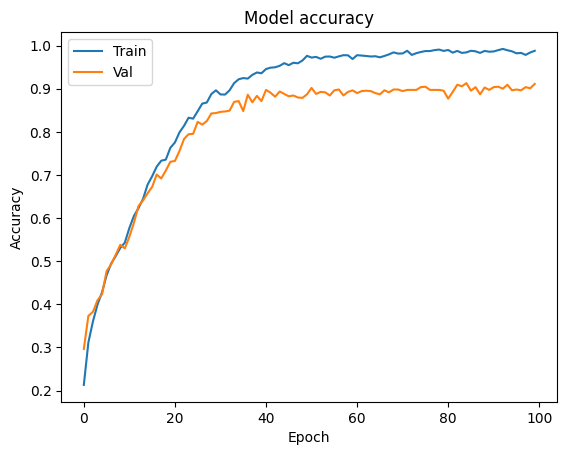

In [61]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

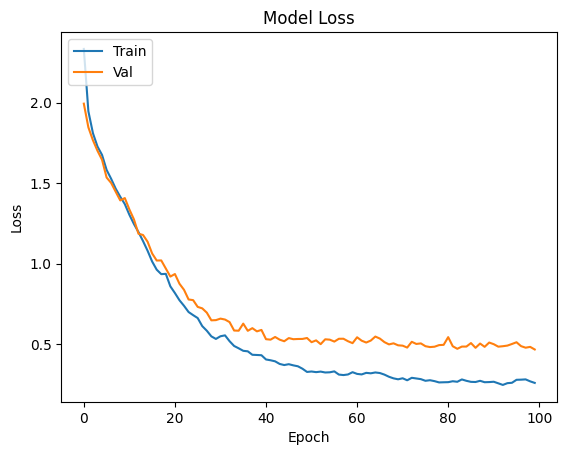

In [62]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [63]:
y_pred = model.predict(XTestProcessed)

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


<Axes: >

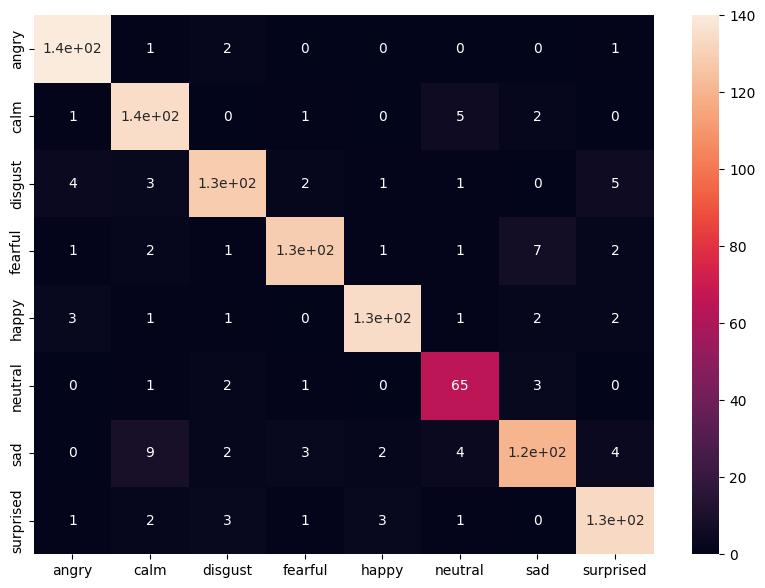

In [64]:
confusion_emotions = ['angry', 'calm', 'disgust', 'fearful','happy','neutral','sad','surprised']
cm=metrics.confusion_matrix(y_test,np.argmax(y_pred,axis=-1))
df_cm=pd.DataFrame(cm,index=[i for i in confusion_emotions],columns=[i for i in confusion_emotions])
plt.figure(figsize=(10,7))
sn.heatmap(df_cm,annot=True)

In [66]:
f1_score(y_test,np.argmax(y_pred,axis=-1),average='weighted')

0.9109662982305079

In [67]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 180, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 180, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 180, 128)       │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 180, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 180, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 22, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 22, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2816)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │        22,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,056,410 (4.03 MB)

 Trainable params: 352,136 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 704,274 (2.69 MB)

In [87]:
# Save the trained model to disk
if not os.path.exists('models'):
    os.makedirs('models')
model.save("models/cnn_model.keras")


In [70]:
# Load the model from disk
loaded_model = keras.models.load_model("models/cnn_model.keras")

In [71]:
# Load the data and extract features for each sound file
def load_single_data(file):
    x, y = [], []
    file_name = os.path.basename(file)
    emotion = emotions[file_name.split("-")[2]]
    data, sr = librosa.load(file)
    feature = extract_feature(data, sr, mfcc=True, chroma=True, mel=True)
    x.append(feature)
    y.append(emotion)
    return np.array(x), y

In [72]:
XX, yy = load_single_data("data/ravdess/Actor_01/03-01-05-02-02-02-01.wav")

In [73]:
yy

['angry']

In [75]:
XXTemp=np.expand_dims(XX, axis=2)
# Assign the prediction result to a new variable
prediction = model.predict(XXTemp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


In [76]:
list(y_pred)

[array([0.00106801, 0.00690728, 0.00791942, 0.00137882, 0.00332053,
        0.97441804, 0.00317606, 0.00181171], dtype=float32),
 array([1.07231387e-03, 1.71570457e-03, 1.40266889e-03, 6.98414078e-05,
        1.12446294e-04, 4.64112003e-04, 9.94629920e-01, 5.32863953e-04],
       dtype=float32),
 array([0.01306478, 0.01022352, 0.00595087, 0.9153099 , 0.02114144,
        0.00666075, 0.01187003, 0.01577865], dtype=float32),
 array([0.00863487, 0.6721496 , 0.04507458, 0.03500945, 0.00260018,
        0.02103954, 0.21393086, 0.0015609 ], dtype=float32),
 array([0.00421633, 0.00531961, 0.00435671, 0.02757891, 0.02625919,
        0.00234126, 0.00245249, 0.9274755 ], dtype=float32),
 array([0.04693574, 0.00244543, 0.01449188, 0.00329944, 0.02356629,
        0.00202454, 0.03341674, 0.87382   ], dtype=float32),
 array([0.04486975, 0.66106576, 0.00317507, 0.0020007 , 0.00346238,
        0.1302066 , 0.15187709, 0.00334258], dtype=float32),
 array([2.4975918e-04, 7.8395504e-07, 2.0556890e-05, 9.868

In [77]:
!pip install streamlit pyngrok librosa


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.0 MB/s eta 0:00:00


In [89]:
import os
print(os.listdir())            # List files/folders in current directory
print(os.path.exists('models'))  # Check if models folder exists
print(os.listdir('models') if os.path.exists('models') else "No models folder")


['boot', 'home', 'root', 'media', 'bin', 'proc', 'lib64', 'tmp', 'libx32', 'var', 'run', 'sbin', 'opt', 'srv', 'sys', 'dev', 'lib', 'mnt', 'usr', 'lib32', 'etc', 'models', 'content', 'X.npy', 'app.py', 'streamlit_log.txt', 'y.npy', 'data', 'kaggle', '.dockerenv', 'datalab', 'tools', 'python-apt', 'python-apt.tar.xz', 'NGC-DL-CONTAINER-LICENSE', 'cuda-keyring_1.1-1_all.deb']
True
['cnn.h5', 'cnn_model.keras']


In [91]:
!mkdir -p "/content/drive/MyDrive/models"


In [92]:
!cp models/cnn_model.keras "/content/drive/MyDrive/models/"
!cp models/cnn.h5 "/content/drive/MyDrive/models/"



In [96]:
%%writefile app.py
import streamlit as st
import librosa
import numpy as np
from keras.models import load_model

# Load trained CNN model
model = load_model("models/cnn_model.keras")

# Emotion labels
emotion_labels = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

# Feature extraction
def extract_feature(data, sr, mfcc=True, chroma=True, mel=True):
    result = np.array([])

    if mfcc:
        mfccs = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)
        result = np.hstack((result, mfccs))

    if chroma:
        stft = np.abs(librosa.stft(data))
        chroma_feat = np.mean(librosa.feature.chroma_stft(S=stft, sr=sr).T, axis=0)
        result = np.hstack((result, chroma_feat))

    if mel:
        mel_spec = np.mean(librosa.feature.melspectrogram(y=data, sr=sr).T, axis=0)
        result = np.hstack((result, mel_spec))

    return result

# Streamlit UI
st.title("Speech Emotion Recognition 🎙️")
uploaded_file = st.file_uploader("Upload a .wav file", type=["wav"])

if uploaded_file:
    st.audio(uploaded_file, format="audio/wav")

    with open("temp.wav", "wb") as f:
        f.write(uploaded_file.read())

    data, sr = librosa.load("temp.wav", sr=None)
    features = extract_feature(data, sr)

    if features is not None:
        input_data = np.expand_dims(features, axis=(0, 2))  # shape: (1, 180, 1)
        prediction = model.predict(input_data)
        predicted_label = emotion_labels[np.argmax(prediction)]

        st.success(f"Predicted Emotion: **{predicted_label.capitalize()}**")


Overwriting app.py


Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/your_path_to_model/cnn_model.keras': No such file or directory


In [97]:
from pyngrok import ngrok
import os

# Kill any existing tunnels
ngrok.kill()

# Set your ngrok authtoken
# Replace "YOUR_AUTHTOKEN" with your actual authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("2xzEAJIPtvxHdOlyllgaV39AmbU_4pJF1trAvWiig2gZZEfaU")

# Start Streamlit app in background
# Ensure app.py is in the correct directory or provide the full path
# You might need to adjust the path to app.py depending on your environment
app_path = "app.py"
if not os.path.exists(app_path):
    print(f"Error: {app_path} not found. Please check the file path.")
else:
    # Use %%bash to run the command in the background and capture output to a file
    # This is often more reliable in Colab for background processes
    get_ipython().run_cell_magic('bash', '', 'streamlit run {} &> streamlit_log.txt &'.format(app_path))

    # Give Streamlit a moment to start
    import time
    time.sleep(5) # Adjust this sleep time if needed

    # Connect to Streamlit via ngrok
    try:
        public_url = ngrok.connect(addr="8501", proto="http")

        print(f"Streamlit app URL: {public_url}")
    except Exception as e:
        print(f"Failed to connect via ngrok: {e}")
        print("Please check the streamlit_log.txt file for potential errors.")


Streamlit app URL: NgrokTunnel: "https://1d4e-34-171-76-176.ngrok-free.app" -> "http://localhost:8501"
